In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(
    "../data/processed/raw_loaded.csv"
)

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,UnitPrice,Customer ID,Country,TotalPrice,PurchaseHour,DayOfWeek
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,7,Tuesday
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,7,Tuesday
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,7,Tuesday
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,7,Tuesday
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,7,Tuesday


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 11 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Invoice       525461 non-null  object 
 1   StockCode     525461 non-null  object 
 2   Description   522533 non-null  object 
 3   Quantity      525461 non-null  int64  
 4   InvoiceDate   525461 non-null  object 
 5   UnitPrice     525461 non-null  float64
 6   Customer ID   417534 non-null  float64
 7   Country       525461 non-null  object 
 8   TotalPrice    525461 non-null  float64
 9   PurchaseHour  525461 non-null  int64  
 10  DayOfWeek     525461 non-null  object 
dtypes: float64(3), int64(2), object(6)
memory usage: 44.1+ MB


In [4]:
df.columns

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'Customer ID', 'Country', 'TotalPrice', 'PurchaseHour',
       'DayOfWeek'],
      dtype='object')

In [5]:
df = df.rename(
    columns={
        "Price":"UnitPrice",
        "Invoice":"InvoiceNo"
    }
)

In [6]:
print("Before:", len(df))

df = df.drop_duplicates()

print("After:", len(df))

Before: 525461
After: 518596


In [7]:
df.isnull().sum()

InvoiceNo            0
StockCode            0
Description       2928
Quantity             0
InvoiceDate          0
UnitPrice            0
Customer ID     107833
Country              0
TotalPrice           0
PurchaseHour         0
DayOfWeek            0
dtype: int64

In [9]:
df = df.dropna(
    subset=[
        "Customer ID",
        "Description"
    ]
)

In [10]:
df.isnull().sum()

InvoiceNo       0
StockCode       0
Description     0
Quantity        0
InvoiceDate     0
UnitPrice       0
Customer ID     0
Country         0
TotalPrice      0
PurchaseHour    0
DayOfWeek       0
dtype: int64

In [11]:
df = df[df["Quantity"] > 0]

df = df[df["UnitPrice"] > 0]

In [12]:
df = df[
    ~df["InvoiceNo"]
      .astype(str)
      .str.startswith("C")
]

In [13]:
df["InvoiceDate"] = pd.to_datetime(
    df["InvoiceDate"]
)

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 400916 entries, 0 to 525460
Data columns (total 11 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   InvoiceNo     400916 non-null  object        
 1   StockCode     400916 non-null  object        
 2   Description   400916 non-null  object        
 3   Quantity      400916 non-null  int64         
 4   InvoiceDate   400916 non-null  datetime64[ns]
 5   UnitPrice     400916 non-null  float64       
 6   Customer ID   400916 non-null  float64       
 7   Country       400916 non-null  object        
 8   TotalPrice    400916 non-null  float64       
 9   PurchaseHour  400916 non-null  int64         
 10  DayOfWeek     400916 non-null  object        
dtypes: datetime64[ns](1), float64(3), int64(2), object(5)
memory usage: 36.7+ MB


In [15]:
df["TotalPrice"] = (
    df["Quantity"]
    *
    df["UnitPrice"]
)

In [16]:
df[[
    "Quantity",
    "UnitPrice",
    "TotalPrice"
]].head()

,Quantity,UnitPrice,TotalPrice
0,12,6.95,83.4
1,12,6.75,81.0
2,12,6.75,81.0
3,48,2.10,100.8
4,24,1.25,30.0


In [17]:
df["Year"] = df["InvoiceDate"].dt.year

df["Month"] = df["InvoiceDate"].dt.month

df["Day"] = df["InvoiceDate"].dt.day

df["Weekday"] = df["InvoiceDate"].dt.day_name()

df["Hour"] = df["InvoiceDate"].dt.hour

df["Quarter"] = df["InvoiceDate"].dt.quarter

In [18]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,Customer ID,Country,TotalPrice,PurchaseHour,DayOfWeek,Year,Month,Day,Weekday,Hour,Quarter
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,7,Tuesday,2009,12,1,Tuesday,7,4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,7,Tuesday,2009,12,1,Tuesday,7,4
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,7,Tuesday,2009,12,1,Tuesday,7,4
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,7,Tuesday,2009,12,1,Tuesday,7,4
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,7,Tuesday,2009,12,1,Tuesday,7,4


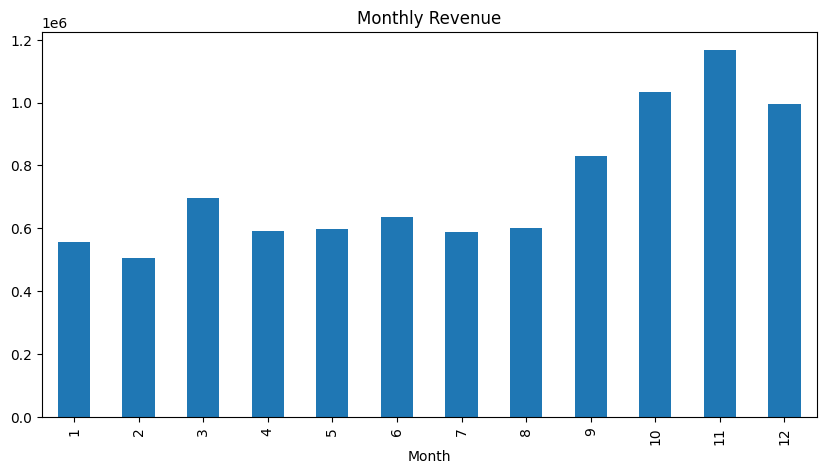

In [19]:
monthly_sales = (
    df.groupby("Month")["TotalPrice"]
      .sum()
)

monthly_sales.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Monthly Revenue")

plt.show()

In [20]:
reference_date = (
    df["InvoiceDate"].max()
    +
    pd.Timedelta(days=1)
)

In [24]:
rfm = df.groupby("Customer ID").agg({

    "InvoiceDate": lambda x:
        (reference_date - x.max()).days,

    "InvoiceNo":"nunique",

    "TotalPrice":"sum"

})

rfm.columns = [

    "Recency",

    "Frequency",

    "Monetary"

]

rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,165,11,372.86
12347.0,3,2,1323.32
12348.0,74,1,222.16
12349.0,43,3,2671.14
12351.0,11,1,300.93


In [25]:
rfm.describe()

,Recency,Frequency,Monetary
count,4312.000000,4312.000000,4312.000000
mean,91.171846,4.455705,2040.406712
std,96.860633,8.170213,8911.755977
min,1.000000,1.000000,2.950000
25%,18.000000,1.000000,307.187500
50%,53.000000,2.000000,701.615000
75%,136.000000,5.000000,1714.932500
max,374.000000,205.000000,349164.350000


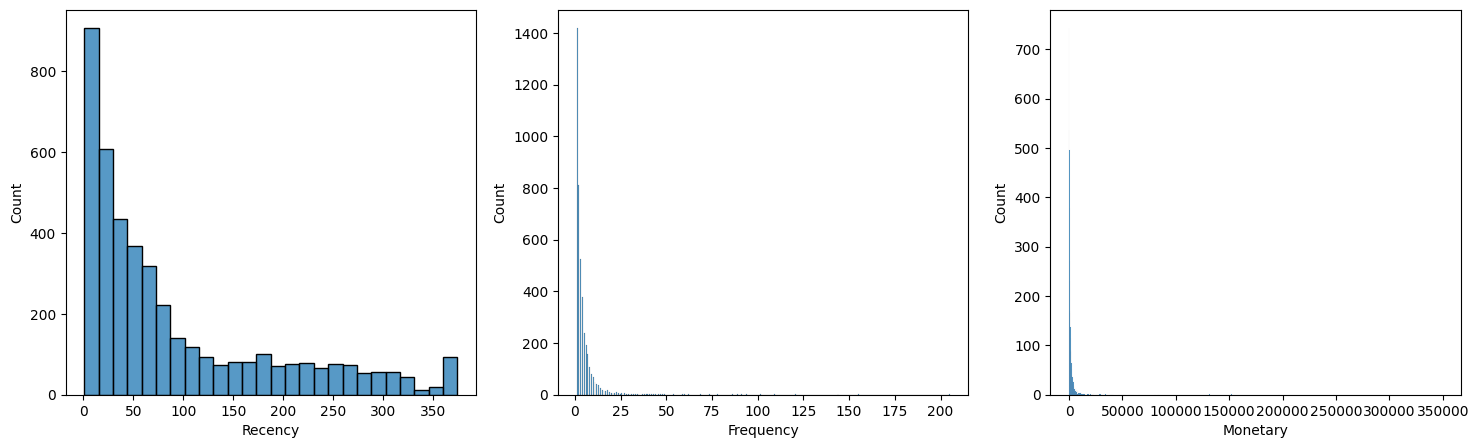

In [26]:
fig, ax = plt.subplots(
    1,
    3,
    figsize=(18,5)
)

sns.histplot(
    rfm["Recency"],
    ax=ax[0]
)

sns.histplot(
    rfm["Frequency"],
    ax=ax[1]
)

sns.histplot(
    rfm["Monetary"],
    ax=ax[2]
)

plt.show()

In [27]:
daily_sales = (
    df.groupby("InvoiceDate")["TotalPrice"]
      .sum()
      .reset_index()
)

In [28]:
daily_sales["Rolling_7"] = (
    daily_sales["TotalPrice"]
    .rolling(7)
    .mean()
)

daily_sales["Rolling_30"] = (
    daily_sales["TotalPrice"]
    .rolling(30)
    .mean()
)

In [29]:
daily_sales.head()

,InvoiceDate,TotalPrice,Rolling_7,Rolling_30
0,2009-12-01 07:45:00,505.30,NaN,NaN
1,2009-12-01 07:46:00,145.80,NaN,NaN
2,2009-12-01 09:06:00,630.33,NaN,NaN
3,2009-12-01 09:08:00,310.75,NaN,NaN
4,2009-12-01 09:24:00,2286.24,NaN,NaN


In [30]:
df.to_csv(
    "../data/processed/cleaned_retail.csv",
    index=False
)

rfm.to_csv(
    "../data/processed/customer_features.csv"
)

daily_sales.to_csv(
    "../data/processed/daily_sales.csv",
    index=False
)

In [31]:
print("Cleaned Dataset Shape:", df.shape)
print("Customer Features Shape:", rfm.shape)
print("Daily Sales Shape:", daily_sales.shape)

Cleaned Dataset Shape: (400916, 17)
Customer Features Shape: (4312, 3)
Daily Sales Shape: (18008, 4)
